# Inference-Only Pipeline — Skip Training, Use Existing Checkpoints

This notebook **skips all training** and uses your existing `phase3_best.pth` checkpoint to:

| Cell | Description |
|------|-------------|
| 1 | Install dependencies |
| 2 | Load EfficientNet-B3 from `phase3_best.pth` (no training) |
| 3 | **Step 8** — CLIP Zero-Shot Grade Classification (A/B/C) |
| 4 | **Step 9** — Depth Anything V2 Volumetric Estimation |
| 5 | **ONNX Export** — Export EfficientNet classifier to `.onnx` |
| 6 | **Full Pipeline Demo** — Type + Grade + Volume on a single image |

**Required files:**
- `checkpoints/phase3_best.pth` (your trained EfficientNet-B3)
- `dataset/unified/test/` (for running grade classification on test set)
- `dataset/conveyor/` (for volumetric estimation)

In [9]:
# ── Cell 1: Install Dependencies ──────────────────────────────────────────
import subprocess, sys

packages = [
    "torch", "torchvision", "Pillow", "numpy", "matplotlib", "tqdm",
    "onnx", "onnxruntime",
    "git+https://github.com/openai/CLIP.git",
    "opencv-python",
    # depth-anything-v2: clone manually — see Step 9 markdown for instructions
]

for pkg in packages:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", pkg],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
    except Exception:
        print(f"  [WARN] Could not install {pkg} — install manually if needed")

print("Dependencies ready.")


Dependencies ready.


---
## Cell 2 — Load EfficientNet-B3 from Existing Checkpoint (No Training)

In [2]:
"""
Load the trained EfficientNet-B3 from phase3_best.pth.
No training happens here — just loading weights.
"""

import os
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import numpy as np
from pathlib import Path
from PIL import Image

# Notebook setup
__file__ = os.path.abspath("pipeline-inference.ipynb")
BASE_DIR = Path(__file__).parent

# ── Device ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))

# ── Constants ─────────────────────────────────────────────────────────────
NUM_CLASSES = 6
IMG_SIZE = 300
CLASS_NAMES = sorted(["HDPE", "LDPE", "OTHER", "PET", "PP", "PS"])
CONFIDENCE_THRESHOLD = 0.70
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

# ── Load Model ────────────────────────────────────────────────────────────
CKPT_PATH = BASE_DIR / "checkpoints" / "phase3_best.pth"
assert CKPT_PATH.exists(), f"Checkpoint not found: {CKPT_PATH}"

efficientnet = models.efficientnet_b3(pretrained=False)
efficientnet.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(1536, 512),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(512, NUM_CLASSES),
)

checkpoint = torch.load(CKPT_PATH, map_location=device)
state_dict = checkpoint.get('model_state_dict', checkpoint)
efficientnet.load_state_dict(state_dict)
efficientnet.to(device).eval()
print(f"EfficientNet-B3 loaded from {CKPT_PATH.name}")

# ── Inference Transform ───────────────────────────────────────────────────
infer_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

# ── Quick sanity check ────────────────────────────────────────────────────
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
with torch.no_grad():
    out = efficientnet(dummy)
print(f"Output shape: {out.shape} — model is working")
print(f"Classes: {CLASS_NAMES}")

Device: cuda (NVIDIA GeForce RTX 3050 6GB Laptop GPU)


d:\hackniche-frontend\Kabo_hn4\backend\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\hackniche-frontend\Kabo_hn4\backend\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\durvi\AppData\Local\Temp\ipykernel_33248\2398306557.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default 

EfficientNet-B3 loaded from phase3_best.pth
Output shape: torch.Size([1, 6]) — model is working
Classes: ['HDPE', 'LDPE', 'OTHER', 'PET', 'PP', 'PS']


---
## Step 8 — Recyclability Grade Classification (CLIP Zero-Shot)

Uses CLIP ViT-B/32 to assign a recyclability grade (A/B/C) to each plastic item.  
**No training needed** — this is zero-shot inference using natural language descriptions.

| Grade | Meaning | Action |
|-------|---------|--------|
| A | Clean, intact, high confidence | Send to recycling stream |
| B | Moderate condition | Pre-process before recycling |
| C | Poor condition, contaminated | Reject or manual review |

Loading CLIP ViT-B/32...


100%|███████████████████████████████████████| 338M/338M [00:40<00:00, 8.64MiB/s]


CLIP loaded


d:\hackniche-frontend\Kabo_hn4\backend\venv\lib\site-packages\torch\nn\functional.py:5560: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


Grade text features encoded

Running hierarchical classification on 973 test images...


100%|██████████| 973/973 [00:39<00:00, 24.49it/s]



Hierarchical Grade Classification Report
Total images: 973

Grade Distribution:
  Grade A:  746 images ( 76.7%) | Avg confidence: 69.4% | Action: Send directly to recycling stream
  Grade B:  156 images ( 16.0%) | Avg confidence: 56.6% | Action: Pre-process before recycling
  Grade C:   27 images (  2.8%) | Avg confidence: 50.2% | Action: Reject — do not recycle
  Grade Unknown:   44 images (  4.5%) | Avg confidence: 0.0% | Action: Flag for human review


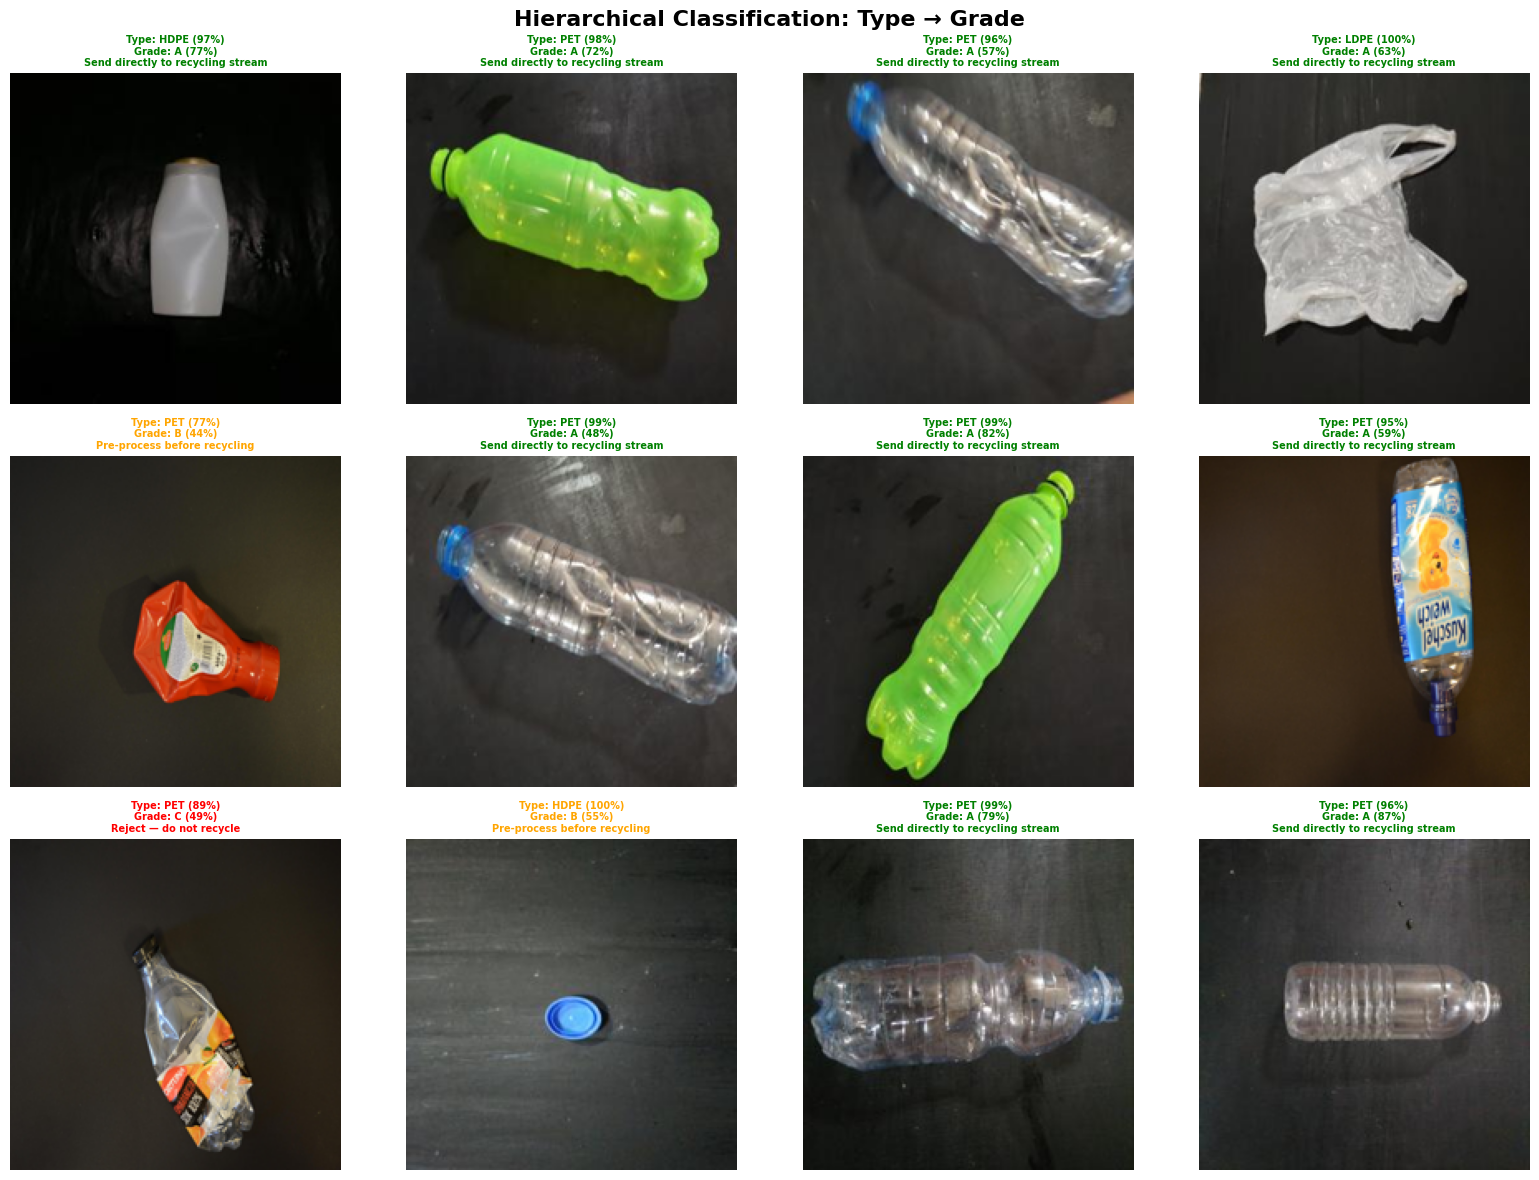

Saved: results/grade_sample_predictions.png

Step 8 complete.


In [3]:
"""
Step 8: CLIP Zero-Shot Grade Classification.
Loads CLIP ViT-B/32 and classifies recyclability grade on the test set.
"""

import clip
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

# ── Load CLIP ─────────────────────────────────────────────────────────────
print("Loading CLIP ViT-B/32...")
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()
print("CLIP loaded")

# ── Grade Descriptions (natural language for zero-shot) ───────────────────
grade_descriptions = [
    "a clean intact plastic item in good condition suitable for recycling",
    "a slightly dirty or mildly damaged plastic item that needs processing before recycling",
    "a heavily contaminated crushed or severely damaged plastic item not suitable for recycling",
]
grade_labels = ['A', 'B', 'C']
grade_actions = {
    'A': 'Send directly to recycling stream',
    'B': 'Pre-process before recycling',
    'C': 'Reject — do not recycle',
}
grade_colors = {'A': 'green', 'B': 'orange', 'C': 'red'}

# Encode text descriptions once
with torch.no_grad():
    text_tokens = clip.tokenize(grade_descriptions).to(device)
    text_features = clip_model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
print("Grade text features encoded")

# ── Grade Classification Function ─────────────────────────────────────────
def classify_grade(pil_image):
    """Given a PIL image, return grade (A/B/C), confidence, and action."""
    image_input = clip_preprocess(pil_image).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = clip_model.encode_image(image_input)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        confidence, pred_idx = similarity[0].max(dim=-1)
    grade = grade_labels[pred_idx.item()]
    return {
        'grade': grade,
        'confidence': confidence.item(),
        'action': grade_actions[grade],
        'all_scores': {grade_labels[i]: similarity[0][i].item() for i in range(3)},
    }

# ── Full Hierarchical Classification ──────────────────────────────────────
def classify_full(pil_image):
    """Stage 1: EfficientNet type → Stage 2: CLIP grade."""
    tensor = infer_transform(pil_image).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = efficientnet(tensor)
        probs = torch.softmax(logits, dim=1)
        type_conf, type_pred = probs.max(dim=1)

    type_conf = type_conf.item()
    plastic_type = CLASS_NAMES[type_pred.item()]

    if type_conf < CONFIDENCE_THRESHOLD:
        return {
            'type': 'Unknown', 'type_confidence': type_conf,
            'grade': 'Unknown', 'grade_confidence': 0.0,
            'action': 'Flag for human review',
        }

    grade_result = classify_grade(pil_image)
    return {
        'type': plastic_type, 'type_confidence': type_conf,
        'grade': grade_result['grade'],
        'grade_confidence': grade_result['confidence'],
        'action': grade_result['action'],
        'grade_scores': grade_result['all_scores'],
    }

# ── Run on Test Set ────────────────────────────────────────────────────────
test_dir = BASE_DIR / "dataset" / "unified" / "test"
all_images = list(test_dir.rglob("*.jpg")) + list(test_dir.rglob("*.jpeg"))
print(f"\nRunning hierarchical classification on {len(all_images)} test images...")

grade_distribution = {'A': 0, 'B': 0, 'C': 0, 'Unknown': 0}
grade_conf_sum = {'A': 0.0, 'B': 0.0, 'C': 0.0}
grade_conf_count = {'A': 0, 'B': 0, 'C': 0}
results_list = []

for img_path in tqdm(all_images):
    img = Image.open(img_path).convert('RGB')
    result = classify_full(img)
    result['path'] = img_path
    results_list.append(result)
    g = result['grade']
    grade_distribution[g] = grade_distribution.get(g, 0) + 1
    if g in grade_conf_sum:
        grade_conf_sum[g] += result['grade_confidence']
        grade_conf_count[g] += 1

# ── Grade Report ──────────────────────────────────────────────────────────
Path("results").mkdir(exist_ok=True)

report_lines = [
    "Hierarchical Grade Classification Report",
    "=" * 45,
    f"Total images: {len(all_images)}",
    "",
    "Grade Distribution:",
]
for g in ['A', 'B', 'C', 'Unknown']:
    count = grade_distribution.get(g, 0)
    pct = count / len(all_images) * 100 if all_images else 0
    avg_conf = (grade_conf_sum.get(g, 0) / grade_conf_count[g] * 100) if grade_conf_count.get(g, 0) > 0 else 0
    action = grade_actions.get(g, 'Flag for human review')
    report_lines.append(f"  Grade {g}: {count:4d} images ({pct:5.1f}%) | Avg confidence: {avg_conf:.1f}% | Action: {action}")

report_text = "\n".join(report_lines)
print("\n" + report_text)

with open("results/grade_report.txt", "w") as f:
    f.write(report_text)

# ── Sample Predictions Grid ───────────────────────────────────────────────
sample_results = random.sample(results_list, min(12, len(results_list)))
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("Hierarchical Classification: Type → Grade", fontsize=16, fontweight='bold')

for ax, res in zip(axes.flat, sample_results):
    img = Image.open(res['path']).convert('RGB').resize((200, 200))
    ax.imshow(img)
    grade = res['grade']
    color = grade_colors.get(grade, 'gray')
    title = (
        f"Type: {res['type']} ({res['type_confidence']*100:.0f}%)\n"
        f"Grade: {grade} ({res['grade_confidence']*100:.0f}%)\n"
        f"{res['action']}"
    )
    ax.set_title(title, fontsize=7, color=color, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.tight_layout()
plt.savefig("results/grade_sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/grade_sample_predictions.png")
print("\nStep 8 complete.")

---
## Step 9 — Volumetric Estimation (Depth Anything V2)

Uses Depth Anything V2 (metric indoor) to estimate real-world volume of each plastic item.  
**No training needed** — pretrained depth model.

**One-time setup (run in terminal before this cell):**
```bash
git clone https://github.com/DepthAnything/Depth-Anything-V2
cd Depth-Anything-V2/metric_depth && pip install -r requirements.txt
```
The notebook will look for the cloned repo at `Depth-Anything-V2/metric_depth` relative to this file.  
Checkpoint `depth_anything_v2_metric_indoor_vitl.pth` must be in `checkpoints/`.


Loading Depth Anything V2 Large (metric indoor)...


C:\Users\durvi\AppData\Local\Temp\ipykernel_33248\2874283450.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  depth_model.load_state_dict(torch.load(str(DEPTH_CHECKPOINT

Depth model loaded

Running volumetric analysis on 95 conveyor images...


100%|██████████| 95/95 [01:01<00:00,  1.54it/s]



Volumetric Estimation Report — Conveyor Belt Dataset
Images processed : 93
Total objects    : 462

Per-Type Volume Summary:
  Class     Items  Total Vol (cm³)   Avg Vol/item  Approx Liters
  --------------------------------------------------------------
  HDPE         38         118931           3130         118.93L  (13.1%)
  OTHER       101         241826           2394         241.83L  (26.7%)
  PET         187         414103           2214         414.10L  (45.7%)
  PP          136         132076            971         132.08L  (14.6%)

  TOTAL       462         906937                        906.94L


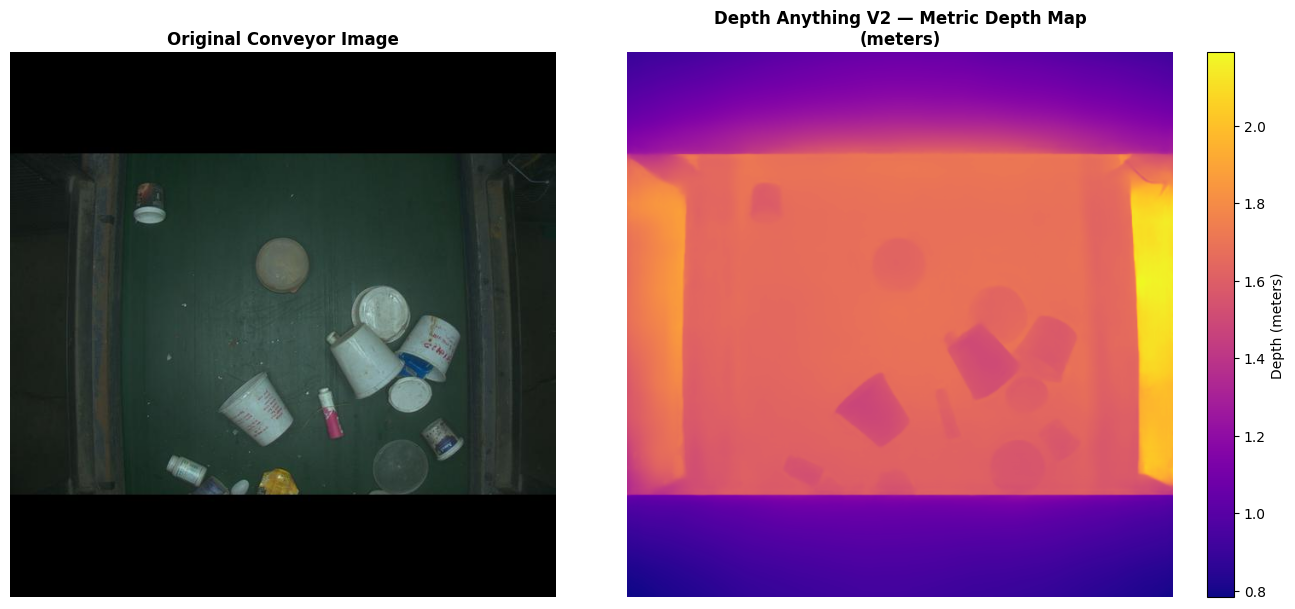

Saved: results/volumetric_sample.png

Step 9 complete — Volumetric estimation done.


In [ ]:
"""
Step 9: Volumetric Estimation using Depth Anything V2 (Metric Indoor, ViT-L).
Runs on conveyor belt images — estimates volume per detected plastic item.
Uses foreground mask (depth percentile) + pixel-count area for better accuracy.
"""

import sys
import cv2
import math
import xml.etree.ElementTree as ET
import matplotlib.patches as patches

# ── Add Depth Anything V2 to path ─────────────────────────────────────────
# Points to the cloned repo (relative to the notebook's directory)
DEPTH_ANYTHING_PATH = str(BASE_DIR / "Depth-Anything-V2" / "metric_depth")
if DEPTH_ANYTHING_PATH not in sys.path:
    sys.path.insert(0, DEPTH_ANYTHING_PATH)

from depth_anything_v2.dpt import DepthAnythingV2

# ── Load Depth Model ──────────────────────────────────────────────────────
model_configs = {
    'vits': {'encoder': 'vits', 'features': 64,  'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
}

ENCODER = 'vitl'
MAX_DEPTH = 20  # meters (indoor)

print("Loading Depth Anything V2 Large (metric indoor)...")
depth_model = DepthAnythingV2(**model_configs[ENCODER], max_depth=MAX_DEPTH)

DEPTH_CHECKPOINT = BASE_DIR / "checkpoints" / "depth_anything_v2_metric_indoor_vitl.pth"
assert DEPTH_CHECKPOINT.exists(), (
    f"Depth checkpoint not found: {DEPTH_CHECKPOINT}\n"
    "Download from: https://huggingface.co/depth-anything/Depth-Anything-V2-Metric-Indoor-Large"
)
depth_model.load_state_dict(torch.load(str(DEPTH_CHECKPOINT), map_location=device))
depth_model.to(device).eval()
print("Depth model loaded")

# ── Helper Functions ──────────────────────────────────────────────────────
CONVEYOR_CLASS_MAP = {
    'mix pp': 'PP', 'mix hd': 'HDPE', 'mix hdpe': 'HDPE',
    'mix pet': 'PET', 'mix rigid': 'OTHER',
}

def parse_conveyor_xml(xml_path):
    """Parse Pascal VOC XML, return list of {class, bbox} dicts."""
    try:
        tree = ET.parse(xml_path)
        objects = []
        for obj in tree.getroot().findall('object'):
            name = obj.find('name').text.lower().strip()
            mapped = CONVEYOR_CLASS_MAP.get(name, 'OTHER')
            bbox = obj.find('bndbox')
            objects.append({
                'class': mapped,
                'bbox': (
                    int(float(bbox.find('xmin').text)),
                    int(float(bbox.find('ymin').text)),
                    int(float(bbox.find('xmax').text)),
                    int(float(bbox.find('ymax').text)),
                ),
            })
        return objects
    except Exception as e:
        print(f"  XML parse error {xml_path}: {e}")
        return []

def estimate_volume_cm3(bbox, depth_map, image_shape):
    """
    Estimate volume proxy in cm³ using:
      A) Foreground mask — 30th-percentile depth threshold isolates the object
         (object is closest to camera; background/conveyor belt is ignored)
      B) Pixel-count area — counts actual foreground pixels instead of full bbox area
         (handles irregular shapes, avoids overestimating empty corners)
    """
    xmin, ymin, xmax, ymax = bbox
    h, w = image_shape[:2]
    xmin, xmax = max(0, xmin), min(w, xmax)
    ymin, ymax = max(0, ymin), min(h, ymax)
    if xmax <= xmin or ymax <= ymin:
        return 0.0, 0.0, 0.0

    crop_depth = depth_map[ymin:ymax, xmin:xmax]

    # Fix A: foreground mask — object pixels are the closest (smallest depth)
    fg_threshold = float(np.percentile(crop_depth, 30))
    fg_mask = crop_depth <= fg_threshold
    fg_pixel_count = int(fg_mask.sum())

    if fg_pixel_count < 10:  # degenerate crop fallback
        fg_mask = np.ones_like(crop_depth, dtype=bool)
        fg_pixel_count = crop_depth.size

    # Use median depth of foreground pixels — robust to outliers
    obj_depth_m = float(np.median(crop_depth[fg_mask]))
    obj_depth_m = max(obj_depth_m, 0.05)

    fov_rad = math.radians(60)  # assumed 60° FOV
    px_to_m = (obj_depth_m * 2 * math.tan(fov_rad / 2)) / w  # full-frame pixel scale

    # Fix B: pixel-count area
    object_area_m2 = fg_pixel_count * (px_to_m ** 2)
    side_cm = math.sqrt(object_area_m2) * 100  # equivalent square side for reporting

    PLASTIC_THICKNESS_CM = 2.0
    volume_cm3 = object_area_m2 * 1e4 * PLASTIC_THICKNESS_CM
    return volume_cm3, side_cm, side_cm

# ── Run Volumetric Analysis on Conveyor Dataset ───────────────────────────
conveyor_img_dir = BASE_DIR / "dataset" / "conveyor" / "img"
conveyor_lbl_dir = BASE_DIR / "dataset" / "conveyor" / "labels"

image_files = sorted(conveyor_img_dir.glob("*.jpeg")) + sorted(conveyor_img_dir.glob("*.jpg"))
print(f"\nRunning volumetric analysis on {len(image_files)} conveyor images...")

Path("results/volumetric_annotated").mkdir(parents=True, exist_ok=True)

volume_totals = {}
count_totals = {}
frame_results = []

for img_path in tqdm(image_files):
    xml_path = conveyor_lbl_dir / (img_path.stem + ".xml")
    if not xml_path.exists():
        continue

    annotations = parse_conveyor_xml(xml_path)
    if not annotations:
        continue

    pil_img = Image.open(img_path).convert('RGB')
    cv2_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

    with torch.no_grad():
        depth_map = depth_model.infer_image(cv2_img)

    annotated = np.array(pil_img).copy()
    frame_summary = {'image': img_path.name, 'objects': []}

    for ann in annotations:
        plastic_class = ann['class']
        bbox = ann['bbox']
        xmin, ymin, xmax, ymax = bbox

        vol_cm3, w_cm, h_cm = estimate_volume_cm3(bbox, depth_map, cv2_img.shape)

        volume_totals[plastic_class] = volume_totals.get(plastic_class, 0.0) + vol_cm3
        count_totals[plastic_class] = count_totals.get(plastic_class, 0) + 1

        frame_summary['objects'].append({
            'class': plastic_class, 'volume_cm3': round(vol_cm3, 1), 'bbox': bbox,
        })

        color_map = {'PET': (0, 255, 0), 'HDPE': (255, 165, 0), 'PP': (0, 0, 255), 'OTHER': (255, 0, 0)}
        color = color_map.get(plastic_class, (128, 128, 128))
        cv2.rectangle(annotated, (xmin, ymin), (xmax, ymax), color, 2)
        label = f"{plastic_class} ~{vol_cm3:.0f}cm3"
        cv2.putText(annotated, label, (xmin, max(ymin - 5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    frame_results.append(frame_summary)
    save_path = f"results/volumetric_annotated/{img_path.stem}_vol.jpg"
    cv2.imwrite(save_path, cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))

# ── Volumetric Report ─────────────────────────────────────────────────────
report_lines = [
    "Volumetric Estimation Report — Conveyor Belt Dataset",
    "=" * 52,
    f"Images processed : {len(frame_results)}",
    f"Total objects    : {sum(count_totals.values())}",
    "",
    "Per-Type Volume Summary:",
    f"  {'Class':<8} {'Items':>6} {'Total Vol (cm³)':>16} {'Avg Vol/item':>14} {'Approx Liters':>14}",
    "  " + "-" * 62,
]

total_vol = sum(volume_totals.values())
for cls in sorted(volume_totals.keys()):
    vol = volume_totals[cls]
    count = count_totals[cls]
    avg = vol / count if count > 0 else 0
    liters = vol / 1000
    pct = vol / total_vol * 100 if total_vol > 0 else 0
    report_lines.append(
        f"  {cls:<8} {count:>6} {vol:>14.0f}   {avg:>12.0f}   {liters:>12.2f}L  ({pct:.1f}%)"
    )

report_lines += [
    "",
    f"  TOTAL    {sum(count_totals.values()):>6} {total_vol:>14.0f}   {'':>12}   {total_vol/1000:>12.2f}L",
]

report_text = "\n".join(report_lines)
print("\n" + report_text)

with open("results/volumetric_report.txt", "w") as f:
    f.write(report_text)

# ── Sample Depth Visualization ────────────────────────────────────────────
if image_files:
    sample_cv2 = cv2.imread(str(image_files[0]))
    with torch.no_grad():
        sample_depth = depth_model.infer_image(sample_cv2)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.imshow(cv2.cvtColor(sample_cv2, cv2.COLOR_BGR2RGB))
    ax1.set_title("Original Conveyor Image", fontweight='bold')
    ax1.axis('off')

    depth_vis = ax2.imshow(sample_depth, cmap='plasma')
    ax2.set_title("Depth Anything V2 — Metric Depth Map\n(meters)", fontweight='bold')
    ax2.axis('off')
    plt.colorbar(depth_vis, ax=ax2, label='Depth (meters)')
    plt.tight_layout()
    plt.savefig("results/volumetric_sample.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: results/volumetric_sample.png")

print("\nStep 9 complete — Volumetric estimation done.")


---
## ONNX Export — Final Deployable Model

Exports the EfficientNet-B3 classifier to ONNX format.  
This is the **deliverable model file** that covers plastic type classification.

**What gets exported:** `phase3_best.pth` → `plastic_classifier.onnx`  
**Input:** `(batch, 3, 300, 300)` normalized image tensor  
**Output:** `(batch, 6)` logits for [HDPE, LDPE, OTHER, PET, PP, PS]

> **Note:** CLIP (grade) and Depth Anything (volume) are runtime-only pretrained models.
> They don't need exporting — they're loaded on-the-fly at inference time.
> The ONNX file covers the core plastic type classification (Stage 1).

In [11]:
"""
ONNX Export — converts phase3_best.pth to plastic_classifier.onnx.
Validates with onnxruntime to ensure correctness.
"""

import onnx
import onnxruntime as ort

ONNX_PATH = BASE_DIR / "results" / "plastic_classifier.onnx"
Path("results").mkdir(exist_ok=True)

# ── Export ─────────────────────────────────────────────────────────────────
print("Exporting EfficientNet-B3 to ONNX...")
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)

torch.onnx.export(
    efficientnet,
    dummy_input,
    str(ONNX_PATH),
    opset_version=11,
    input_names=["image"],
    output_names=["logits"],
    dynamic_axes={"image": {0: "batch_size"}, "logits": {0: "batch_size"}},
    verbose=False,
)
print(f"  Exported → {ONNX_PATH}")

# ── Validate Structure ────────────────────────────────────────────────────
onnx_model = onnx.load(str(ONNX_PATH))
onnx.checker.check_model(onnx_model)
print("  ONNX structure check — OK")

# ── Verify with onnxruntime ───────────────────────────────────────────────
providers = ["CUDAExecutionProvider", "CPUExecutionProvider"] if torch.cuda.is_available() else ["CPUExecutionProvider"]
sess = ort.InferenceSession(str(ONNX_PATH), providers=providers)

dummy_np = dummy_input.cpu().numpy()
ort_out = sess.run(None, {"image": dummy_np})
torch_out = efficientnet(dummy_input).detach().cpu().numpy()

max_diff = float(np.abs(ort_out[0] - torch_out).max())
print(f"  onnxruntime vs PyTorch max diff: {max_diff:.6f}")
assert max_diff < 1e-2, f"ONNX verification failed: diff={max_diff}"
print("  ONNX verification — OK")

# ── File size ─────────────────────────────────────────────────────────────
size_mb = ONNX_PATH.stat().st_size / (1024 * 1024)
print(f"\n  Final ONNX model: {ONNX_PATH}")
print(f"  Size: {size_mb:.1f} MB")
print(f"  Input: (batch, 3, 300, 300) — normalized RGB image")
print(f"  Output: (batch, 6) — logits for {CLASS_NAMES}")
print(f"\n  Apply softmax to logits to get class probabilities.")
print(f"  argmax → predicted class, max softmax → confidence.")

Exporting EfficientNet-B3 to ONNX...
  Exported → d:\hackniche-frontend\Kabo_hn4\backend\results\plastic_classifier.onnx
  ONNX structure check — OK


d:\hackniche-frontend\Kabo_hn4\backend\venv\lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


  onnxruntime vs PyTorch max diff: 0.001035
  ONNX verification — OK

  Final ONNX model: d:\hackniche-frontend\Kabo_hn4\backend\results\plastic_classifier.onnx
  Size: 43.8 MB
  Input: (batch, 3, 300, 300) — normalized RGB image
  Output: (batch, 6) — logits for ['HDPE', 'LDPE', 'OTHER', 'PET', 'PP', 'PS']

  Apply softmax to logits to get class probabilities.
  argmax → predicted class, max softmax → confidence.


---
## Full Pipeline Demo — Single Image → Type + Grade + Volume

Run all 3 stages on a single image to see the complete output.
This is exactly what the FastAPI backend does when you POST an image.

In [ ]:
"""
Full Pipeline Demo: Type → Grade → Volume on a single image.
Change DEMO_IMAGE to test with any image.
"""

import json

# ── Pick a demo image ─────────────────────────────────────────────────────
# Use a test image, or replace with your own path
test_images = list((BASE_DIR / "dataset" / "unified" / "test").rglob("*.jpg"))
if not test_images:
    test_images = list((BASE_DIR / "dataset" / "conveyor" / "img").glob("*.jpeg"))

DEMO_IMAGE = test_images[0] if test_images else None
assert DEMO_IMAGE, "No demo image found — place an image in dataset/unified/test/"

print(f"Demo image: {DEMO_IMAGE.name}\n")
img = Image.open(DEMO_IMAGE).convert('RGB')

# ── Stage 1: Plastic Type (EfficientNet) ──────────────────────────────────
tensor = infer_transform(img).unsqueeze(0).to(device)
with torch.no_grad():
    logits = efficientnet(tensor)
    probs = torch.softmax(logits, dim=1)
    type_conf, type_pred = probs.max(dim=1)

plastic_type = CLASS_NAMES[type_pred.item()]
type_confidence = type_conf.item()
print(f"Stage 1 — Type:  {plastic_type}  (confidence: {type_confidence:.2%})")

# ── Stage 2: Grade (CLIP) ─────────────────────────────────────────────────
grade_result = classify_grade(img)
print(f"Stage 2 — Grade: {grade_result['grade']}  (confidence: {grade_result['confidence']:.2%})")
print(f"           Action: {grade_result['action']}")
print(f"           Scores: A={grade_result['all_scores']['A']:.2%}  B={grade_result['all_scores']['B']:.2%}  C={grade_result['all_scores']['C']:.2%}")

# ── Stage 3: Volume (Depth Anything) ──────────────────────────────────────
# Fix A: foreground mask (30th percentile) isolates the object from background
# Fix B: pixel-count area instead of full-image bbox area
volume_result = None
try:
    cv2_img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    h, w = cv2_img.shape[:2]
    with torch.no_grad():
        depth_map = depth_model.infer_image(cv2_img)

    # Fix A: object is closest thing — threshold at 30th percentile
    fg_threshold = float(np.percentile(depth_map, 30))
    fg_mask = depth_map <= fg_threshold
    fg_pixel_count = int(fg_mask.sum())
    if fg_pixel_count < 10:
        fg_mask = np.ones(depth_map.shape, dtype=bool)
        fg_pixel_count = depth_map.size

    obj_depth_m = float(np.median(depth_map[fg_mask]))
    obj_depth_m = max(obj_depth_m, 0.05)

    fov_rad = math.radians(60)
    px_to_m = (obj_depth_m * 2 * math.tan(fov_rad / 2)) / w

    # Fix B: pixel-count area
    object_area_m2 = fg_pixel_count * (px_to_m ** 2)
    side_mm = math.sqrt(object_area_m2) * 1000  # equivalent square side
    volume_mm3 = object_area_m2 * 1e6 * 20.0    # m² → mm² × 20mm thickness

    print(f"Stage 3 — Volume: {volume_mm3:.1f} mm³")
    print(f"           Est. footprint: {side_mm:.1f} × {side_mm:.1f} mm  (fg pixels: {fg_pixel_count})")
    volume_result = {"volume_mm3": round(volume_mm3, 1), "width_mm": round(side_mm, 1), "height_mm": round(side_mm, 1)}
except NameError:
    print("Stage 3 — Volume: SKIPPED (Depth model not loaded — run Step 9 first)")

# ── Combined JSON Output ──────────────────────────────────────────────────
output = {
    "plastic_type": plastic_type,
    "type_confidence": round(type_confidence, 4),
    "grade": grade_result['grade'],
    "grade_confidence": round(grade_result['confidence'], 4),
    "grade_scores": {k: round(v, 4) for k, v in grade_result['all_scores'].items()},
    "action": grade_result['action'],
    "volume_mm3": volume_result["volume_mm3"] if volume_result else None,
    "dimensions": {"width_mm": volume_result["width_mm"], "height_mm": volume_result["height_mm"]} if volume_result else None,
}

print(f"\n{'='*50}")
print("FULL API RESPONSE (JSON):")
print('='*50)
print(json.dumps(output, indent=2))

# ── Display ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(img)
ax.set_title(
    f"Type: {plastic_type} ({type_confidence:.0%})  |  "
    f"Grade: {grade_result['grade']} ({grade_result['confidence']:.0%})\n"
    f"{grade_result['action']}",
    fontsize=10, fontweight='bold',
    color=grade_colors.get(grade_result['grade'], 'black'),
)
ax.axis('off')
plt.tight_layout()
plt.show()

print("\nDone! Your deliverables:")
print(f"  ONNX model   → results/plastic_classifier.onnx")
print(f"  Grade report  → results/grade_report.txt")
print(f"  Volume report → results/volumetric_report.txt")
